# Inspect HSC/HST PSF FITS files

Use this notebook to check which HDUs, headers, image shapes, pixel scales, and data values are present before using a FITS PSF in `train_stg_1_2.py`.

In [2]:
# Install once if needed:
# !pip install astropy

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from astropy.io import fits


In [10]:
# Change this path to one of your PSF FITS files.
fits_path = Path("C:/Users/upraj/Prajwal/GSOC/DeepLense/Data/psf/psf/HSC_PSF/psf-calexp-pdr2_wide-HSC-I-15828-1,2-239.38410-42.10650.fits")
# fits_path = Path("C:/Users/upraj/Prajwal/GSOC/DeepLense/Data/psf/psf/MAST_2026-06-22T0825/WFPC2PSF/ua1o2302m_10730403_F606W_calibrated_cutout.fits")

with fits.open(fits_path, memmap=False) as hdul:
    # Astropy's built-in HDU table. This prints index, name, type, cards, dimensions, and format.
    hdul.info()

    rows = []
    for idx, hdu in enumerate(hdul):
        data = hdu.data
        header = hdu.header
        rows.append({
            "index": idx,
            "name": hdu.name,
            "type": type(hdu).__name__,
            "shape": None if data is None else tuple(data.shape),
            "dtype": None if data is None else str(data.dtype),
            "BUNIT": header.get("BUNIT"),
            "CDELT1": header.get("CDELT1"),
            "CDELT2": header.get("CDELT2"),
            "PIXSCALE": header.get("PIXSCALE") or header.get("PIXSCAL1"),
            "EXTNAME": header.get("EXTNAME"),
        })

pd.DataFrame(rows)


Filename: C:\Users\upraj\Prajwal\GSOC\DeepLense\Data\psf\psf\HSC_PSF\psf-calexp-pdr2_wide-HSC-I-15828-1,2-239.38410-42.10650.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      18   (41, 41)   float64   


,index,name,type,shape,dtype,BUNIT,CDELT1,CDELT2,PIXSCALE,EXTNAME
0,0,PRIMARY,PrimaryHDU,"(41, 41)",>f8,None,None,None,None,None


In [11]:
# Inspect headers for a candidate PSF HDU.
# If the primary HDU has no data, try hdu_index = 1 or use an EXTNAME from the table above.
hdu_index = 0

with fits.open(fits_path, memmap=False) as hdul:
    header = hdul[hdu_index].header
    print(repr(header))


SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                  -64 / number of bits per data pixel                  
NAXIS   =                    2 / number of data axes                            
NAXIS1  =                   41 / length of data axis 1                          
NAXIS2  =                   41 / length of data axis 2                          
EXTEND  =                    T / FITS dataset may contain extensions            
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
CTYPE1A = 'LINEAR  '           / Type of projection                             
CTYPE2A = 'LINEAR  '           / Type of projection                             
CRPIX1A =                   1. / Column Pixel Coordinate of Reference           
CRPIX2A =                   1. / Row Pixel Coordinate of Reference              
CRVAL1A =                669

shape: (41, 41)
sum: 1.0
min / max: 0.0 0.08926945128180787
argmax [y, x]: (np.int64(20), np.int64(20))


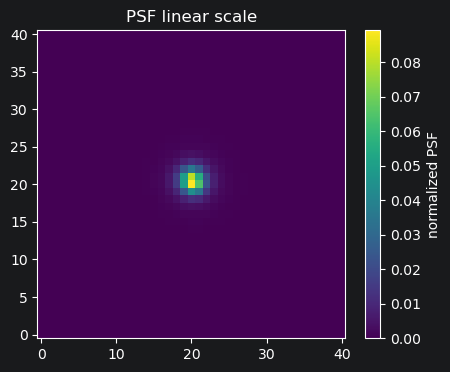

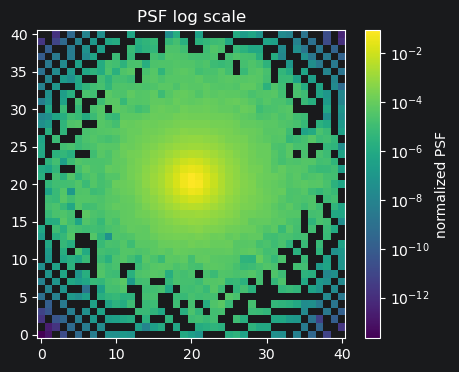

In [12]:
# Load and visualize the candidate PSF image.
# This matches the loader behavior in psf.py: squeeze singleton dimensions,
# and if a cube remains, take the first plane until it becomes 2D.
hdu_index = 0

with fits.open(fits_path, memmap=False) as hdul:
    arr = hdul[hdu_index].data
    if arr is None:
        # Fall back to the first HDU containing image data.
        for h in hdul:
            if h.data is not None:
                arr = h.data
                break

arr = np.squeeze(np.asarray(arr))
while arr.ndim > 2:
    arr = arr[0]

arr = np.nan_to_num(arr.astype(float), nan=0.0, posinf=0.0, neginf=0.0)
arr = np.clip(arr, 0.0, None)
psf = arr / arr.sum()

print("shape:", psf.shape)
print("sum:", psf.sum())
print("min / max:", psf.min(), psf.max())
print("argmax [y, x]:", np.unravel_index(np.argmax(psf), psf.shape))

plt.figure(figsize=(5, 4))
plt.imshow(psf, origin="lower")
plt.colorbar(label="normalized PSF")
plt.title("PSF linear scale")
plt.show()

positive = psf[psf > 0]
plt.figure(figsize=(5, 4))
plt.imshow(psf, origin="lower", norm=LogNorm(vmin=positive.min(), vmax=psf.max()))
plt.colorbar(label="normalized PSF")
plt.title("PSF log scale")
plt.show()


## Training usage

For HSC LR training, pass the HSC PSF FITS as the degradation PSF. Example:

```bash
python train_stg_1_2.py \
  --exp-name hsc_fits_psf \
  --resolution 0.168 \
  --epochs 100 \
  --batch-size 200 \
  --magnification 2 \
  --n-mag 1 \
  --psf-type fits \
  --psf-path path/to/hsc_psf.fits \
  --psf-fits-hdu 0 \
  --psf-source-pixscale-arcsec 0.168 \
  --psf-fits-crop-size 65 \
  --downsample-mode area \
  --log-train True
```

Set `--psf-source-pixscale-arcsec` to the native pixel scale of the PSF stamp. The loader resamples the kernel to `resolution / magnification` before convolving the HR lensed image.